# C2.3 Angular Momentum
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.3.1 Spin and Orbital Angular Momentum: A Quick Recap

In the previous phase, we introduced two types of angular motion:

- **Orbital angular momentum**: From the motion of the center of mass (CM) of an object around an external point.
- **Spin angular momentum**: From the rotation of the object around its own CM.

Back then, we kept things simple—usually assuming fixed axes or symmetric shapes. But in the real world, objects can be **asymmetric**, spinning about **arbitrary axes**, while also **moving through space**. Time to go deeper.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.3.2 Objective

Our goal in this lesson is to understand how to describe the **full angular momentum** of a rigid body when it's both **translating through space** and **rotating**—and not just in simple, symmetric cases.

Up to now, we’ve worked mostly with spin around fixed axes, and occasionally mentioned orbital angular momentum. But to analyze real-world motion—whether it’s a spinning satellite tumbling in space or a football flying and spinning through the air—we need tools that go beyond simple scalar quantities.

By the end of this lesson, you should be able to:

- Separate a rigid body’s angular momentum into **orbital** and **spin** components.
- Understand how **angular velocity** relates to the **spin angular momentum** of an object.
- Derive and use the **moment of inertia tensor**, which captures how mass is distributed relative to different axes of rotation.
- Express spin angular momentum as a matrix-vector product:  
  
  $$
  \vec{L}_{\text{spin}} = \mathbf{I} \cdot \vec{\omega}
  $$

This sets the foundation for understanding complex rotation in 3D and leads directly into our upcoming work on **principal axes** and **gyroscopic motion**.


<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.3.3 Total Angular Momentum of a Rigid Body

Let’s consider a rigid body made up of many particles. The total angular momentum about a fixed origin $ O $ is:

$$
\vec{L} = \sum_i \vec{r}_i \times m_i \vec{v}_i
$$

We now split each particle’s position and velocity into two parts (see Figure below for visual aid):

- $ \vec{r}_i = \vec{R} + \vec{r}'_i $: position of particle = CM position + position relative to CM
- $ \vec{v}_i = \vec{V} + \vec{v}'_i $: velocity of particle = CM velocity + velocity relative to CM



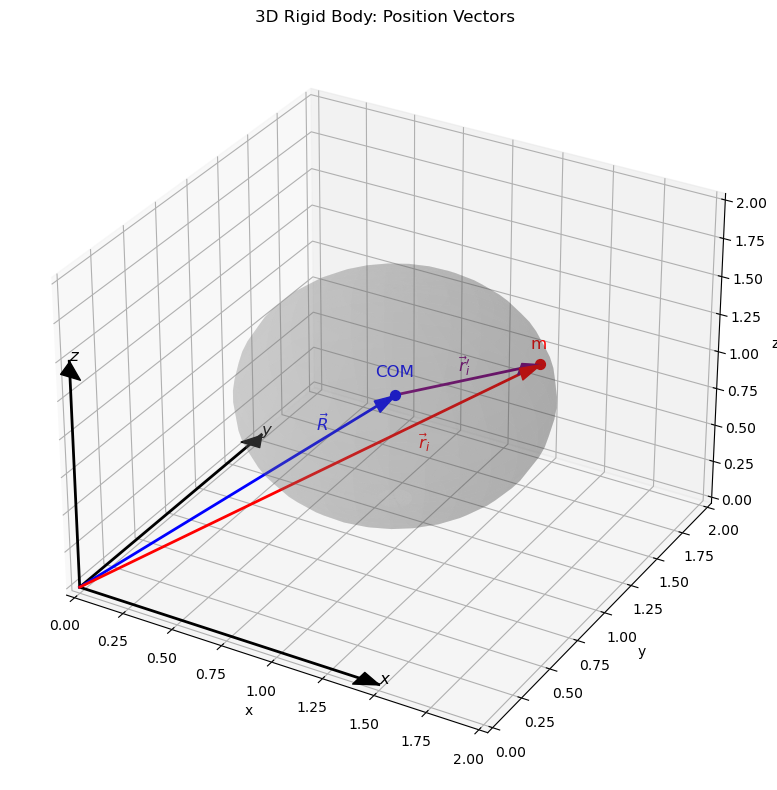

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Function to plot an arrow with a solid triangular head
def draw_arrow(ax, start, end, color, label=None, label_offset=np.array([0, 0, 0])):
    # Draw shaft
    ax.plot([start[0], end[0]],
            [start[1], end[1]],
            [start[2], end[2]], color=color, linewidth=2)

    # Draw arrowhead
    head_length = 0.1
    head_width = 0.05
    direction = end - start
    direction = direction / np.linalg.norm(direction)

    if np.allclose(direction, [0, 0, 1]):
        not_collinear = np.array([0, 1, 0])
    else:
        not_collinear = np.array([0, 0, 1])

    side1 = np.cross(direction, not_collinear)
    side1 = side1 / np.linalg.norm(side1) * head_width

    base = end - direction * head_length
    triangle = [end, base + side1, base - side1]
    arrow_head = Poly3DCollection([triangle], color=color)
    ax.add_collection3d(arrow_head)

    # Label
    if label:
        ax.text(*(end + label_offset), label, color=color, fontsize=12)

# Create figure and 3D axes
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Set axes limits and labels
ax.set_xlim([0, 2])
ax.set_ylim([0, 2])
ax.set_zlim([0, 2])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

# Define points
origin = np.array([0, 0, 0])
R = np.array([1, 1, 1])             # Center of mass
r_i = np.array([1.6, 1.2, 1.3])     # Infinitesimal element
r_prime = r_i - R

# Define label offset vectors (adjust as needed)
com_label_offset = np.array([-0.1, 0, 0.08])
dm_label_offset = np.array([-0.05, 0, 0.08])
R_vec_label_offset = np.array([-0.4, 0, -0.4])
r_vec_label_offset = np.array([-0.6, 0, -0.8])
r_prime_label_offset = np.array([-0.4, 0, -0.2])

# Plot coordinate axes
draw_arrow(ax, origin, np.array([1.5, 0, 0]), 'black', r'$x$')
draw_arrow(ax, origin, np.array([0, 1.5, 0]), 'black', r'$y$')
draw_arrow(ax, origin, np.array([0, 0, 1.5]), 'black', r'$z$')

# Plot vectors with labels and custom offsets
draw_arrow(ax, origin, R, 'blue', r'$\vec{R}$', R_vec_label_offset)
draw_arrow(ax, origin, r_i, 'red', r'$\vec{r}_i$', r_vec_label_offset)
draw_arrow(ax, R, r_i, 'purple', r'$\vec{r}^\prime_i$', r_prime_label_offset)

# Plot markers for COM and dm
ax.scatter(*R, color='blue', s=50)
ax.scatter(*r_i, color='red', s=50)

# Add point labels with vertical offset
ax.text(*(R + com_label_offset), 'COM', color='blue', fontsize=12)
ax.text(*(r_i + dm_label_offset), 'm', color='red', fontsize=12)

# Transparent ellipsoid object around COM
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x = 0.7 * np.outer(np.cos(u), np.sin(v)) + R[0]
y = 0.7 * np.outer(np.sin(u), np.sin(v)) + R[1]
z = 0.7 * np.outer(np.ones_like(u), np.cos(v)) + R[2]
ax.plot_surface(x, y, z, color='gray', alpha=0.2, edgecolor='none')

plt.title('3D Rigid Body: Position Vectors')
plt.tight_layout()
plt.show()


Plug into the expression for $ \vec{L} $:

$$
\vec{L} = \sum_i (\vec{R} + \vec{r}'_i) \times m_i (\vec{V} + \vec{v}'_i)
$$

Expanding this:

$$
\vec{L} = \vec{R} \times \left( \sum_i m_i \vec{V} \right)
+ \sum_i \vec{r}'_i \times m_i \vec{V}
+ \vec{R} \times \left( \sum_i m_i \vec{v}'_i \right)
+ \sum_i \vec{r}'_i \times m_i \vec{v}'_i
$$

Now simplify:

- $ \sum_i m_i \vec{V} = M \vec{V} $ → total mass times CM velocity
- $ \sum_i m_i \vec{r}'_i = 0 $ by definition of CM
- $ \sum_i m_i \vec{v}'_i = 0 $ for rigid body (no net internal motion)

If we are not convinced about the statements of the later two, we can show it:

$$ 
\sum_i m_i\vec{r}'_i = \sum_i m_i(\vec{r}_i - \vec{R}) = \sum_i m_i\vec{r}_i - \sum_i m_i\vec{R} = MR - MR = 0 
$$

The angular momentum is then:

$$
\vec{L} = \vec{R} \times M\vec{V} + \sum_i \vec{r}'_i \times m_i \vec{v}'_i
$$

This is the key result:

- The first term is **orbital angular momentum** (CM motion).
- The second term is **spin angular momentum** (rotation about the CM).

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.3.4 Modeling the Spin Term with Angular Velocity

For a **rigid body**, the velocity of a point relative to the CM is (all particles will have the same angular velocity):

$$
\vec{v}'_i = \vec{\omega} \times \vec{r}'_i
$$

So the spin term becomes:

$$
\vec{L}_{\text{spin}} = \sum_i \vec{r}'_i \times m_i (\vec{\omega} \times \vec{r}'_i)
$$

This double cross product is messy but standard using the triple product expansion (also known as Lagrange's formula):

$$ \vec{A}\times(\vec{B}\times\vec{C}) = (\vec{A}\cdot\vec{C})\vec{B} - (\vec{A}\cdot\vec{B})\vec{C}
$$

With that, we get

$$
\vec{L}_{\text{spin}} = \sum_i m_i \left[ (\vec{r}'_i \cdot \vec{r}'_i)\vec{\omega} - (\vec{r}'_i \cdot \vec{\omega})\vec{r}'_i \right] \tag{1}
$$

We now define a linear transformation that maps $ \vec{\omega} $ to $ \vec{L}_{\text{spin}} $. This is done using a tensor object: the **moment of inertia tensor**.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.3.5 Deriving the Moment of Inertia Tensor

Let’s write this transformation in component form:

$$
L_j = \sum_k I_{jk} \omega_k \tag{2}
$$

where the **moment of inertia tensor** $ \mathbf{I} $ has components:

$$
I_{jk} = \sum_i m_i \left( \delta_{jk} r_i'^2 - r'_{i,j} r'_{i,k} \right)
$$

Or, in matrix form:

$$
\vec{L}_{\text{spin}} = \mathbf{I} \cdot \vec{\omega}
$$

This tensor captures how mass is distributed in **all directions**. It’s a 3×3 symmetric matrix and generalizes the scalar moment of inertia to arbitrary shapes and axes.

<div class="alert alert-warning">
    
**Box 1**
   
Verify the above by calculating the x-component of the angular momentum using Equations 1 and 2 separately and compare the two results.
    
</div>

NOTE: The diagonal terms in the moment of inertia tensor are called **moment of inertia**, while the off-diagonal terms are called **products of inertia**.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.3.6 Summary: What You Now Know

- The **total angular momentum** of a rigid body is:

  $$
  \vec{L} = M \vec{R} \times \vec{V} + \mathbf{I} \cdot \vec{\omega}
  $$

- The first term is from CM motion (orbital), the second from internal rotation (spin).
- The **moment of inertia tensor** maps angular velocity $ \vec{\omega} $ to angular momentum.
- For symmetric shapes and rotation about principal axes, the tensor becomes diagonal and easy to work with.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## C2.3.7 Up Next 

In the next phase, we’ll explore how to **diagonalize the inertia tensor**, find **principal axes**, and understand why rotating bodies sometimes behave so weirdly (hello, **intermediate axis theorem** aka known as the **tennis racket theorem** 👀).

<hr style="height:2px;border-width:0;color:gray;background-color:gray">